# MCP-Bench: Tool DAG Similarity & Consistency Analysis

This notebook analyses the structural consistency of tool dependency graphs (DAGs) produced by LLM agents across repeated runs of the same tasks. The core question it answers is: **given the same prompt, how consistently does a model produce the same execution plan?**

The analysis is built in layers:
- **Sections 1–3** establish clean, validated data
- **Section 4** defines all reusable metric functions
- **Sections 5–7** perform the actual analyses
- **Section 8** produces all visualisations

Each analysis section depends only on the functions defined in Section 4 and the dataframes produced by earlier sections. Sections 7 and 8 contain no new graph-level computation — only aggregations and plots of data already built upstream.

---
## Section 1: Setup & Imports

### Rationale
All dependencies, configuration constants, and global plot settings live in this section. Keeping everything here means the notebook can be re-run cleanly from the top without hunting for scattered imports. It also makes the dependency surface explicit — anyone reading the notebook can see at a glance what libraries are required.

This section has no analytical content. It is purely infrastructural.

### 1.1 — Package installation

**Purpose:** Ensure all required packages are available in the environment.

A `pip install` cell using the `!` shell escape. Should install:
- `networkx` — graph construction and all DAG-level operations
- `numpy` — matrix operations on the pairwise similarity matrices
- `scipy` — hierarchical clustering (`linkage`, `fcluster`) and condensed distance matrix conversion (`squareform`)
- `pandas` — tabular storage of per-task, per-model result dataframes
- `matplotlib` — base plotting
- `seaborn` — heatmaps and styled statistical plots
- `scikit-learn` — MDS embedding for the 2D scatter visualisation

Mark this cell so it can be skipped if the environment is already set up (e.g. a comment `# run once`).

In [45]:
# run once
!pip install networkx numpy scipy pandas matplotlib seaborn scikit-learn

### 1.2 — Imports

**Purpose:** Load all libraries in a single cell so that re-running any later cell never fails due to a missing import.

Group imports logically:
1. Standard library (`json`, `pathlib`, `itertools`, `collections`)
2. Third-party data/graph (`networkx`, `numpy`, `pandas`, `scipy`)
3. Machine learning (`sklearn.manifold.MDS`)
4. Visualisation (`matplotlib`, `seaborn`)

Set a consistent random seed here for any stochastic operations (MDS, clustering) so results are reproducible across re-runs.

In [46]:
import json
import sys
from pathlib import Path
from itertools import combinations
from collections import defaultdict

import networkx as nx
import numpy as np
import pandas as pd
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Locate build_network.py whether Jupyter is started from project root or analysis/
_cwd = Path(".").resolve()
_analysis_dir = _cwd if (_cwd / "build_network.py").exists() else _cwd / "analysis"
sys.path.insert(0, str(_analysis_dir))
from build_network import load_all_records, extract_records, load_records

random_seed = 42
np.random.seed(random_seed)
print("Imports OK")

Imports OK


### 1.3 — Configuration constants

**Purpose:** Centralise all magic numbers and file paths so nothing is hardcoded deeper in the notebook.

Should define:
- `DATA_PATH` — path to the raw JSON/JSONL output file from MCP-Bench
- `GROUND_TRUTH_PATH` — path to the ground truth graph definitions
- `MODEL_LIST` — the explicit list of model identifiers present in the data
- `N_REPS` — number of repetitions per task × model combination
- `SIMILARITY_THRESHOLD` — the Jaccard cutoff below which two graphs are considered meaningfully different (used in outlier detection later)
- `CONSISTENCY_CLUSTER_DISTANCE` — the Ward linkage distance threshold used to count plan clusters per task

Making these constants explicit here means they can be tuned without touching any analysis cell.

In [47]:
import build_network as _bm
DATA_DIR = Path(_bm.__file__).parent / "agent_plans_json"  # always relative to build_network.py
MODEL_LIST = ["minimax-m2.7"]       # model identifiers present in the data
SIMILARITY_THRESHOLD = 0.5            # Jaccard cutoff for "meaningfully different"
CONSISTENCY_CLUSTER_DISTANCE = 0.4    # Ward linkage distance threshold for cluster count
EXCLUDED = set()                       # (task_id, variation_id, model, rep) keys — filled by section 3

print(f"DATA_DIR: {DATA_DIR}")

DATA_DIR: /home/maxro/mcp-bench/analysis/agent_plans_json


### 1.4 — Plot style defaults

**Purpose:** Set global matplotlib/seaborn aesthetics once so all plots in the notebook share a consistent look.

Should set figure size defaults, DPI, colour palette, font sizes, and spine/grid visibility. Doing this here prevents each plotting cell from needing its own style boilerplate.

In [48]:
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 100,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_theme(style="whitegrid", palette="muted")

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
print(f"Figures will be saved to: {FIGURES_DIR.resolve()}")

Figures will be saved to: /home/maxro/mcp-bench/analysis/figures


---
## Section 2: Data Loading & Graph Construction

### Rationale
Before any metric can be computed, raw JSON records must be converted into `networkx.DiGraph` objects — the data structure that all later functions operate on. This section is the only place in the notebook where files are read from disk. Everything downstream works with the in-memory graph objects produced here.

Separating loading from analysis means that if the raw data format changes, only this section needs updating.

The primary output is two nested dictionaries:
- `llm_graphs[(task_id, model, rep)]` → `nx.DiGraph`
- `ground_truth_graphs[task_id]` → `nx.DiGraph`

All keys are tuples so they can be easily grouped, filtered, and iterated.

### 2.1 — `load_raw_records(path)`

**Purpose:** Read the MCP-Bench output file and return a list of raw record dicts.

Handles:
- JSON array format (single `json.load`) and JSONL format (line-by-line `json.loads`)
- Raises a clear error if the file is missing or malformed, rather than failing silently later

Returns a flat list of dicts, each containing at minimum: `task_id`, `model`, `rep`, `llm_graph`, and `ground_truth_graph`.

In [49]:
def load_raw_records(path=None):
    """Load planning records from a single file or all files in DATA_DIR.

    Parameters
    ----------
    path : str or Path, optional
        If None, loads all *.json from DATA_DIR.
        If a path, loads that single file (JSON array or single dict or JSONL).

    Returns
    -------
    list[dict]  — flat list of record dicts as produced by build_network.extract_records()
    """
    if path is None:
        return load_all_records(DATA_DIR)

    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    with open(path) as f:
        content = f.read().strip()

    if content.startswith("["):
        # JSON array of planning-results dicts
        items = json.loads(content)
        records = []
        for item in items:
            records.extend(extract_records(item))
        return records
    elif content.startswith("{"):
        # Single planning-results dict
        return load_records(path)
    else:
        # JSONL — one planning-results dict per line
        records = []
        for line in content.splitlines():
            line = line.strip()
            if line:
                records.extend(extract_records(json.loads(line)))
        return records

### 2.2 — `build_dag(graph_record)`

**Purpose:** Convert a single raw graph record (a dict with `nodes` and `edges` fields) into a `networkx.DiGraph`.

Nodes should use the tool name string as the node identifier — this is what makes edge Jaccard work without any alignment step. If the record uses numeric IDs with a separate name field, this function resolves the mapping so that all downstream edges are `(tool_name_a, tool_name_b)` tuples.

Any node-level metadata (e.g. tool category, MCP server) should be stored as node attributes on the graph for potential use in later analyses.

In [50]:
def build_dag(record):
    """Return the pre-built LLM DiGraph from a record dict.

    build_network.py already constructs nx.DiGraph objects during load_all_records(),
    so this is a thin accessor — no re-parsing required.
    Node identifiers are tool-name strings; edges are (parent_tool, child_tool).
    """
    return record["llm_graph"]

### 2.3 — `build_all_graphs(records)`

**Purpose:** Apply `build_dag()` to every record and organise the results into the two lookup dictionaries.

Iterates over all records, calling `build_dag()` on both the `llm_graph` and `ground_truth_graph` fields. Stores LLM graphs under the `(task_id, variation_id, model, rep)` key and ground truth graphs under `task_id` alone, deduplicating since the ground truth is the same across all repetitions of a task.

Prints a summary on completion: total records loaded, unique tasks, models, and reps per task.

In [51]:
def build_all_graphs(records):
    """Populate llm_graphs and ground_truth_graphs from a flat list of records.

    Returns
    -------
    llm_graphs : dict  (task_id, variation_id, model, rep) -> nx.DiGraph
    ground_truth_graphs : dict  task_id -> nx.DiGraph
    """
    llm_g = {}
    gt_g = {}

    for r in records:
        task_id = r["task_id"]
        variation_id = r["variation_id"]
        model = r["model"]
        rep = r["repetition"]
        llm_g[(task_id, variation_id, model, rep)] = r["llm_graph"]
        gt_g[task_id] = r["ground_truth_graph"]   # same GT for all variants/reps; last write wins

    unique_tasks = len(set(k[0] for k in llm_g))
    unique_models = len(set(k[2] for k in llm_g))
    reps_per_task = (
        pd.Series([k[0] for k in llm_g]).value_counts().to_dict()
        if llm_g else {}
    )

    print(f"Records loaded     : {len(records)}")
    print(f"Unique tasks       : {unique_tasks}")
    print(f"Unique models      : {unique_models}")
    print(f"Ground truth graphs: {len(gt_g)}")
    print(f"Reps per task      : {reps_per_task}")

    return llm_g, gt_g

### 2.4 — Execution cell

**Purpose:** Call the loading pipeline and store the result in `llm_graphs` and `ground_truth_graphs`.

A single short cell that calls `load_raw_records()` then `build_all_graphs()`. Keeping the function definitions separate from the call makes it easy to reload data with a different path without re-running definition cells.

In [95]:
records = load_all_records()
llm_graphs, ground_truth_graphs = build_all_graphs(records)

gt_graph = ground_truth_graphs.get("metropolitan_museum_huge_icons_wikipedia_000")


nodes = gt_graph.number_of_nodes()
edges = gt_graph.number_of_edges()

print(f"Number of nodes is {nodes} and number of edges is {edges}")




Records loaded     : 30
Unique tasks       : 1
Unique models      : 1
Ground truth graphs: 1
Reps per task      : {'metropolitan_museum_huge_icons_wikipedia_000': 30}
Number of nodes is 0 and number of edges is 0


---
## Section 3: Sanity Checks & Data Overview

### Rationale
Graph similarity metrics assume the inputs are valid DAGs. If any LLM output contains a cycle, it is structurally broken and will produce misleading similarity scores — a reversed edge looks like a hallucination rather than a direction error. These checks must run before any metric computation.

This section also surfaces the basic shape of the dataset — size distributions, vocabulary coverage — so that later results can be interpreted in context. For example, knowing that a task's ground truth has 3 nodes vs. 15 nodes is essential context when reading its consistency score.

Any graphs that fail validation are added to an `EXCLUDED` set and skipped in all downstream cells.

### 3.1 — `check_dag_validity(graphs)`

**Purpose:** Run `nx.is_directed_acyclic_graph()` on every LLM graph and return a report of failures.

Returns a dataframe with columns `task_id`, `model`, `rep`, `is_valid`, and `cycle` (the offending cycle if one is found). Prints a summary count of valid vs. invalid graphs.

Graphs that fail are stored in a module-level `EXCLUDED` set — a set of `(task_id, model, rep)` tuples that all later functions will skip. This ensures cycle-containing outputs never silently corrupt similarity calculations.

In [53]:
def check_dag_validity(graphs):
    """Run nx.is_directed_acyclic_graph on every LLM graph.

    Populates the global EXCLUDED set with keys of cyclic graphs.

    Returns
    -------
    pd.DataFrame  columns: task_id, model, rep, is_valid, cycle
    """
    global EXCLUDED
    rows = []

    for (task_id, variation_id, model, rep), G in graphs.items():
        is_valid = nx.is_directed_acyclic_graph(G)
        cycle = None
        if not is_valid:
            try:
                cycle = nx.find_cycle(G)
            except nx.NetworkXNoCycle:
                pass
            EXCLUDED.add((task_id, variation_id, model, rep))
        rows.append({
            "task_id": task_id,
            "variation_id": variation_id,
            "model": model,
            "rep": rep,
            "is_valid": is_valid,
            "cycle": str(cycle) if cycle else None,
        })

    df = pd.DataFrame(rows)
    n_valid = df["is_valid"].sum()
    n_invalid = len(df) - n_valid
    print(f"Valid graphs  : {n_valid} / {len(df)}")
    print(f"Invalid graphs: {n_invalid}")
    if n_invalid > 0:
        print("EXCLUDED keys:", EXCLUDED)
        print(df[~df["is_valid"]].to_string(index=False))
    return df


validity_df = check_dag_validity(llm_graphs)

Valid graphs  : 29 / 30
Invalid graphs: 1
EXCLUDED keys: {('metropolitan_museum_huge_icons_wikipedia_000', 2, 'minimax-m2.7', 6)}
                                     task_id  variation_id        model  rep  is_valid                                                                                cycle
metropolitan_museum_huge_icons_wikipedia_000             2 minimax-m2.7    6     False [('Metropolitan Museum:get-museum-object', 'Metropolitan Museum:get-museum-object')]


### 3.2 — Graph size distribution

**Purpose:** Plot histograms of node count and edge count across all LLM graphs and ground truth graphs side by side.

Shows whether LLM outputs are systematically larger or smaller than the ground truth. A heavy right tail (some very large LLM graphs) is an early signal of hallucination-heavy tasks. A heavy left tail suggests the model is under-generating tools.

Also print the min, median, and max node/edge count for both LLM and ground truth distributions.

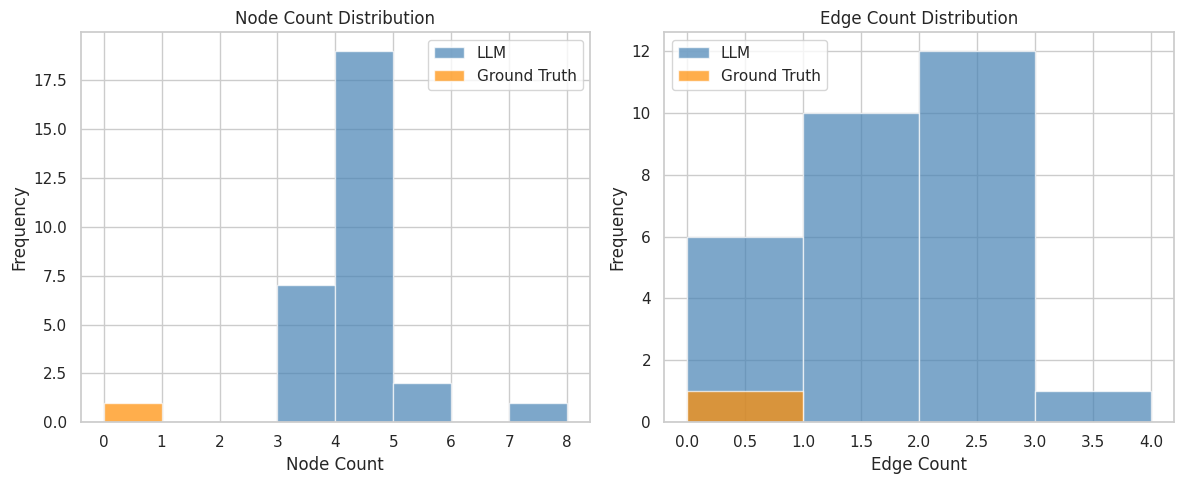

LLM — nodes: min=3, median=4.0, max=7 | edges: min=0, median=1.0, max=3
GT  — nodes: min=0, median=0.0, max=0 | edges: min=0, median=0.0, max=0


In [54]:
llm_node_counts = [G.number_of_nodes() for k, G in llm_graphs.items() if k not in EXCLUDED]
llm_edge_counts = [G.number_of_edges() for k, G in llm_graphs.items() if k not in EXCLUDED]
gt_node_counts  = [G.number_of_nodes() for G in ground_truth_graphs.values()]
gt_edge_counts  = [G.number_of_edges() for G in ground_truth_graphs.values()]

all_nodes = llm_node_counts + gt_node_counts
all_edges = llm_edge_counts + gt_edge_counts
max_nodes = max(all_nodes) + 2 if all_nodes else 5
max_edges = max(all_edges) + 2 if all_edges else 5

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(llm_node_counts, bins=range(max_nodes), alpha=0.7, label="LLM", color="steelblue")
axes[0].hist(gt_node_counts,  bins=range(max_nodes), alpha=0.7, label="Ground Truth", color="darkorange")
axes[0].set_xlabel("Node Count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Node Count Distribution")
axes[0].legend()

axes[1].hist(llm_edge_counts, bins=range(max_edges), alpha=0.7, label="LLM", color="steelblue")
axes[1].hist(gt_edge_counts,  bins=range(max_edges), alpha=0.7, label="Ground Truth", color="darkorange")
axes[1].set_xlabel("Edge Count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Edge Count Distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "size_distribution.png", bbox_inches="tight")
plt.show()

for label, nc, ec in [("LLM", llm_node_counts, llm_edge_counts), ("GT ", gt_node_counts, gt_edge_counts)]:
    if nc:
        print(f"{label} — nodes: min={min(nc)}, median={np.median(nc):.1f}, max={max(nc)} | "
              f"edges: min={min(ec)}, median={np.median(ec):.1f}, max={max(ec)}")

### 3.3 — Tool vocabulary coverage

**Purpose:** Extract the full set of unique tool names seen across all LLM graphs and compare it to the ground truth vocabulary.

Identifies:
- Tools that appear in LLM graphs but never in any ground truth — candidate hallucination names at the global level
- Tools that appear in ground truth but never in any LLM graph — tools the models collectively never use

Print both sets as sorted lists. This is a global view; per-task tool analysis is in Section 6.

In [55]:
llm_vocab = set()
for k, G in llm_graphs.items():
    if k not in EXCLUDED:
        llm_vocab.update(G.nodes())

gt_vocab = set()
for G in ground_truth_graphs.values():
    gt_vocab.update(G.nodes())

hallucination_candidates = sorted(llm_vocab - gt_vocab)
never_used_gt_tools      = sorted(gt_vocab - llm_vocab)

print(f"LLM vocabulary size : {len(llm_vocab)}")
print(f"GT  vocabulary size : {len(gt_vocab)}")

print(f"\nHallucination candidates — in LLM but not GT ({len(hallucination_candidates)}):")
for t in hallucination_candidates:
    print(f"  {t}")

print(f"\nNever-used GT tools — in GT but not any LLM graph ({len(never_used_gt_tools)}):")
for t in never_used_gt_tools:
    print(f"  {t}")

LLM vocabulary size : 15
GT  vocabulary size : 0

Hallucination candidates — in LLM but not GT (15):
  Huge Icons:get_platform_usage
  Huge Icons:list_icons
  Huge Icons:search_icons
  Huge Icons__get_platform_usage
  Huge Icons__list_icons
  Huge Icons__search_icons
  Math MCP__ceiling
  Metropolitan Museum:get-museum-object
  Metropolitan Museum:get_museum_object
  Metropolitan Museum:list_departments
  Metropolitan Museum:search-museum-objects
  Metropolitan Museum:search_museum_objects
  Metropolitan Museum__get-museum-object
  Metropolitan Museum__list-departments
  Metropolitan Museum__search-museum-objects

Never-used GT tools — in GT but not any LLM graph (0):


### 3.4 — Coefficient of variation (CV) of graph size per task

**Purpose:** For each task × model group, compute the CV of node count and edge count across repetitions.

CV = std / mean. A high CV means the model cannot decide how complex the plan should be — some runs produce 4-node graphs, others produce 12-node graphs for the same prompt. These high-CV tasks are likely candidates for the bimodal plan distributions detected more precisely in Section 5.

Output as a sortable table. Flag the top 10% highest-CV tasks for attention in later sections.

In [56]:
task_model_groups_raw = defaultdict(list)
for (task_id, variation_id, model, rep), G in llm_graphs.items():
    if (task_id, variation_id, model, rep) not in EXCLUDED:
        task_model_groups_raw[(task_id, variation_id, model)].append(G)

cv_rows = []
for (task_id, variation_id, model), graphs in task_model_groups_raw.items():
    nc = [G.number_of_nodes() for G in graphs]
    ec = [G.number_of_edges() for G in graphs]
    node_mean, node_std = np.mean(nc), np.std(nc)
    edge_mean, edge_std = np.mean(ec), np.std(ec)
    cv_rows.append({
        "task_id": task_id,
        "model": model,
        "n_reps": len(graphs),
        "node_mean": round(node_mean, 2),
        "node_cv":   round(node_std / node_mean, 3) if node_mean > 0 else 0.0,
        "edge_mean": round(edge_mean, 2),
        "edge_cv":   round(edge_std / edge_mean, 3) if edge_mean > 0 else 0.0,
    })

cv_df = pd.DataFrame(cv_rows).sort_values("edge_cv", ascending=False)

# Flag top 10% by node_cv or edge_cv
q90_node = cv_df["node_cv"].quantile(0.9)
q90_edge = cv_df["edge_cv"].quantile(0.9)
cv_df["high_cv"] = (cv_df["node_cv"] >= q90_node) | (cv_df["edge_cv"] >= q90_edge)

print("CV of graph size per (task_id, model):")
print(cv_df.to_string(index=False))

CV of graph size per (task_id, model):
                                     task_id        model  n_reps  node_mean  node_cv  edge_mean  edge_cv  high_cv
metropolitan_museum_huge_icons_wikipedia_000 minimax-m2.7       9       3.78    0.110        1.0    0.943     True
metropolitan_museum_huge_icons_wikipedia_000 minimax-m2.7      10       4.50    0.205        1.2    0.624     True
metropolitan_museum_huge_icons_wikipedia_000 minimax-m2.7      10       3.50    0.143        1.6    0.415    False


---
## Section 4: Core Similarity & Error Metric Functions

### Rationale
All metric logic lives here as pure functions with no side effects — no printing, no plotting, no dataframe construction. This section is a library, not an analysis.

The design principle is that every function takes one or two `nx.DiGraph` objects and returns a scalar or dict. This makes them composable: the pairwise matrix function calls the scalar function N² times; the per-task consistency function calls the pairwise matrix function.

Keeping metrics here means any section can call them, and swapping in a new metric later (e.g. WL kernel similarity instead of edge Jaccard) requires changing only this section — nothing downstream breaks.

### 4.1 — `edge_jaccard(G1, G2) → float`

**Purpose:** Compute the Jaccard similarity between the edge sets of two directed graphs.

Formula: `|edges(G1) ∩ edges(G2)| / |edges(G1) ∪ edges(G2)|`

Edges are `(source, target)` tuples — direction matters. Since nodes are named tool strings, edges compare directly with no alignment step. Returns 1.0 if both graphs are empty (both trivially identical), 0.0 if they share no edges at all.

This is the primary similarity signal used throughout the notebook. A high score means the same tool dependencies are wired the same way.

In [57]:
def edge_jaccard(G1, G2):
    """Jaccard similarity between the edge sets of two directed graphs.

    Returns 1.0 if both graphs are empty (trivially identical).
    Direction matters: (u, v) != (v, u).
    """
    e1 = set(G1.edges())
    e2 = set(G2.edges())
    if not e1 and not e2:
        return 1.0
    return len(e1 & e2) / len(e1 | e2)

### 4.2 — `node_jaccard(G1, G2) → float`

**Purpose:** Compute Jaccard similarity on node sets only, ignoring edges entirely.

Formula: `|nodes(G1) ∩ nodes(G2)| / |nodes(G1) ∪ nodes(G2)|`

Used as a companion signal to edge Jaccard. When edge Jaccard is low, node Jaccard disambiguates the cause: if node Jaccard is also low, the model is selecting different tools entirely; if node Jaccard is high but edge Jaccard is low, the model has the right tools but wires them differently. These are very different failure modes requiring different interventions.

In [58]:
def node_jaccard(G1, G2):
    """Jaccard similarity between the node sets of two directed graphs.

    Companion to edge_jaccard:
    - high node_j + low edge_j  → correct tool selection, wrong wiring
    - low  node_j + low edge_j  → different tool selection entirely
    """
    n1 = set(G1.nodes())
    n2 = set(G2.nodes())
    if not n1 and not n2:
        return 1.0
    return len(n1 & n2) / len(n1 | n2)

### 4.3 — `edge_precision_recall_f1(G_pred, G_gt) → dict`

**Purpose:** Compute precision, recall, and F1 of the predicted graph's edges against the ground truth.

- **Precision** = correct edges / all predicted edges → how many of the model's dependency claims are correct
- **Recall** = correct edges / all ground truth edges → how many required dependencies did the model capture
- **F1** = harmonic mean of the two

Unlike Jaccard (which treats both directions of error symmetrically), P/R/F1 reveals *which direction* the model errs in: low precision = hallucinating extra edges; low recall = missing required edges. This asymmetry is critical for model comparison in Section 7.

In [59]:
def edge_precision_recall_f1(G_pred, G_gt):
    """Precision, recall, and F1 of predicted graph edges against a ground truth.

    - Precision: fraction of predicted edges that are correct
    - Recall:    fraction of GT edges that were predicted
    - F1:        harmonic mean

    Returns dict with keys: precision, recall, f1
    """
    pred = set(G_pred.edges())
    gt   = set(G_gt.edges())

    if not pred and not gt:
        return {"precision": 1.0, "recall": 1.0, "f1": 1.0}

    tp        = len(pred & gt)
    precision = tp / len(pred) if pred else 0.0
    recall    = tp / len(gt)   if gt   else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    return {"precision": precision, "recall": recall, "f1": f1}

### 4.4 — `directionality_errors(G1, G2) → int`

**Purpose:** Count the number of edges that exist in both graphs but with direction reversed.

For each edge `(u, v)` in G1, check whether `(v, u)` exists in G2 while `(u, v)` does not. These are cases where the model identified the correct tool pair but got the dependency direction wrong — a qualitatively different error from a missing edge, since the tools are present and connected, just in the wrong order.

Returns a raw count. Callers can normalise by total edge count to produce a rate.

In [60]:
def directionality_errors(G1, G2):
    """Count edges that exist in both graphs but with direction reversed.

    For each (u, v) in G1: counts it if (v, u) is in G2 and (u, v) is not.
    This captures cases where the tool pair is identified correctly but the
    dependency arrow is flipped — a qualitatively different error from a missing edge.
    """
    e2 = set(G2.edges())
    return sum(1 for u, v in G1.edges() if (v, u) in e2 and (u, v) not in e2)

### 4.5 — `critical_path_delta(G1, G2) → int`

**Purpose:** Compute the absolute difference in longest path length between two DAGs.

Uses `nx.dag_longest_path_length()` on both graphs and returns `|len(G1) - len(G2)|`. A delta of 0 means both plans have the same critical path depth even if they differ in other ways. A large delta means the model is producing a fundamentally shallower or deeper dependency chain than the reference.

When comparing against ground truth, this captures whether the model preserved the sequential depth of the task even if individual edges differ.

In [61]:
def critical_path_delta(G1, G2):
    """Absolute difference in longest path length between two DAGs.

    Returns 0 if both graphs have the same critical-path depth.
    Handles empty graphs and non-DAGs gracefully.
    """
    def _longest(G):
        if G.number_of_nodes() == 0:
            return 0
        try:
            return nx.dag_longest_path_length(G)
        except nx.NetworkXUnfeasible:
            return 0

    return abs(_longest(G1) - _longest(G2))

### 4.6 — `pairwise_similarity_matrix(graphs) → np.ndarray`

**Purpose:** Given a list of `nx.DiGraph` objects, compute the full N×N pairwise edge Jaccard similarity matrix.

The matrix is symmetric with 1.0 on the diagonal. Only the upper triangle is computed; the lower triangle is filled by reflection to avoid redundant computation.

This is the central data structure for all repetition consistency analysis. It is called once per `(task_id, model)` group, passing the K repetition graphs for that group. The resulting matrix is then passed to `variability_stats()`.

In [62]:
def pairwise_similarity_matrix(graphs):
    """Compute the full N×N pairwise edge Jaccard similarity matrix.

    Matrix is symmetric with 1.0 on the diagonal.
    Only the upper triangle is computed; lower is filled by reflection.

    Parameters
    ----------
    graphs : list[nx.DiGraph]

    Returns
    -------
    np.ndarray  shape (N, N)
    """
    n = len(graphs)
    mat = np.eye(n)
    for i in range(n):
        for j in range(i + 1, n):
            sim = edge_jaccard(graphs[i], graphs[j])
            mat[i, j] = sim
            mat[j, i] = sim
    return mat

### 4.7 — `variability_stats(similarity_matrix) → dict`

**Purpose:** Summarise a pairwise similarity matrix into a set of scalar statistics that characterise the consistency of a group of graphs.

Extracts the upper triangle (unique pairs only), converts to distances (`1 - similarity`), and computes:
- `mean_similarity` — the overall consistency score for this group
- `std_similarity` — spread; low std means the model is reliably consistent or reliably inconsistent
- `min_similarity` — worst-case divergence; the most different pair of plans in the group
- `n_clusters` — number of distinct plan families detected via Ward hierarchical clustering at `CONSISTENCY_CLUSTER_DISTANCE`
- `centroid_idx` — index of the graph with the lowest mean distance to all others; the most representative plan in the group
- `outlier_mask` — boolean array identifying runs whose mean distance to others exceeds mean + 2×std

Returns a dict. The calling loop converts this dict into a row of `consistency_df`.

In [96]:
def variability_stats(similarity_matrix):
    """Summarise a pairwise similarity matrix into scalar consistency statistics.

    Parameters
    ----------
    similarity_matrix : np.ndarray  shape (N, N)

    Returns
    -------
    dict with keys:
        mean_similarity, std_similarity, min_similarity,
        n_clusters, centroid_idx, outlier_mask
    """
    n = similarity_matrix.shape[0]

    if n == 1:
        return {
            "mean_similarity": 1.0,
            "std_similarity":  0.0,
            "min_similarity":  1.0,
            "n_clusters":      1,
            "centroid_idx":    0,
            "outlier_mask":    np.array([False]),
        }

    upper_idx = np.triu_indices(n, k=1)
    pairwise_sims = similarity_matrix[upper_idx]

    mean_sim = float(np.mean(pairwise_sims))
    std_sim  = float(np.std(pairwise_sims))
    min_sim  = float(np.min(pairwise_sims))

    # Ward clustering on condensed distance matrix
    condensed = np.clip(squareform(1 - similarity_matrix), 0, None)
    Z = linkage(condensed, method="ward")
    labels = fcluster(Z, t=CONSISTENCY_CLUSTER_DISTANCE, criterion="distance")
    n_clusters = int(len(set(labels)))

    # Centroid: graph with lowest mean distance to all others
    mean_dists = (1 - similarity_matrix).mean(axis=1)
    centroid_idx = int(np.argmin(mean_dists))

    # Outlier mask: mean_dist > global_mean + 2 * global_std
    threshold = mean_dists.mean() + 2 * mean_dists.std()
    outlier_mask = mean_dists > threshold

    return {
        "mean_similarity": mean_sim,
        "std_similarity":  std_sim,
        "min_similarity":  min_sim,
        "n_clusters":      n_clusters,
        "centroid_idx":    centroid_idx,
        "outlier_mask":    outlier_mask,
    }

### 4.8 — `classify_errors(G_pred, G_gt) → dict`

**Purpose:** Decompose the difference between a predicted graph and the ground truth into a structured taxonomy of error types.

Returns counts for each category:
- `missing_nodes` — tools in the ground truth not present in the prediction
- `hallucinated_nodes` — tools in the prediction not present in the ground truth
- `missing_edges` — dependency edges in the ground truth not captured
- `hallucinated_edges` — dependency edges in the prediction not in the ground truth
- `direction_errors` — edges present in both but with direction reversed

Note: missing edges whose endpoints are also missing nodes should be counted separately from missing edges whose endpoints are both present — the latter is a purer wiring error and more informative.

In [64]:
def classify_errors(G_pred, G_gt):
    """Decompose errors between a predicted graph and ground truth into typed categories.

    Returns
    -------
    dict with counts for:
        missing_nodes, hallucinated_nodes,
        missing_edges, missing_edges_pure_wiring, missing_edges_with_missing_node,
        hallucinated_edges, direction_errors
    """
    pred_nodes = set(G_pred.nodes())
    gt_nodes   = set(G_gt.nodes())
    pred_edges = set(G_pred.edges())
    gt_edges   = set(G_gt.edges())

    missing_nodes      = gt_nodes - pred_nodes
    hallucinated_nodes = pred_nodes - gt_nodes

    missing_edges_total = gt_edges - pred_edges
    # Pure wiring error: both endpoints are present but the edge is absent
    missing_edges_pure_wiring      = {(u, v) for u, v in missing_edges_total
                                       if u in pred_nodes and v in pred_nodes}
    missing_edges_with_missing_node = missing_edges_total - missing_edges_pure_wiring

    hallucinated_edges = pred_edges - gt_edges

    direction_errors = sum(
        1 for u, v in pred_edges
        if (v, u) in gt_edges and (u, v) not in gt_edges
    )

    return {
        "missing_nodes":                    len(missing_nodes),
        "hallucinated_nodes":               len(hallucinated_nodes),
        "missing_edges":                    len(missing_edges_total),
        "missing_edges_pure_wiring":        len(missing_edges_pure_wiring),
        "missing_edges_with_missing_node":  len(missing_edges_with_missing_node),
        "hallucinated_edges":               len(hallucinated_edges),
        "direction_errors":                 direction_errors,
    }

---
## Section 5: Repetition Consistency Analysis

### Rationale
This is the core analysis section. It answers: **for a fixed task and model, how much do the generated plans vary across repeated runs?**

The approach is to group graphs by `(task_id, model)`, compute the pairwise similarity matrix within each group, and extract summary statistics using `variability_stats()`. This produces a flat `consistency_df` dataframe — one row per `(task_id, model)` — that all subsequent sections aggregate from.

Beyond the scalar summary, this section also builds two per-element stability measures: edge frequency (how often each `(u→v)` dependency appears across repetitions) and node frequency (how often each tool appears). These are richer than the scalar stats and support the visualisations in Section 8.

### 5.1 — Build `consistency_df`

**Purpose:** Iterate over all `(task_id, model)` groups, compute the pairwise similarity matrix, and collect `variability_stats()` output into a single dataframe.

For each group:
1. Collect the K repetition graphs, filtering out any whose key appears in `EXCLUDED`
2. Call `pairwise_similarity_matrix()` on them
3. Call `variability_stats()` on the result
4. Append a row to the output with `task_id`, `model`, and all stat fields

The resulting `consistency_df` is the central output of this section. Every later analysis either filters, groups, or pivots it. Print its shape and a grouped summary (mean consistency per model) on completion.

In [65]:
# Build (task_id, model) groups, excluding invalid graphs
task_model_groups = defaultdict(list)   # (task_id, model) → [DiGraph, ...]
task_model_rep_ids = defaultdict(list)  # (task_id, model) → [rep, ...]

for (task_id, variation_id, model, rep), G in sorted(llm_graphs.items()):
    if (task_id, variation_id, model, rep) not in EXCLUDED:
        task_model_groups[(task_id, variation_id, model)].append(G)
        task_model_rep_ids[(task_id, variation_id, model)].append(rep)

# Cache similarity matrices for reuse in sections 5.5 and 8
_sim_matrices = {}   # (task_id, model) → np.ndarray

consistency_rows = []
for (task_id, variation_id, model), graphs in task_model_groups.items():
    sim_mat = pairwise_similarity_matrix(graphs)
    _sim_matrices[(task_id, variation_id, model)] = sim_mat
    stats = variability_stats(sim_mat)
    consistency_rows.append({
        "task_id":         task_id,
        "variation_id":    variation_id,
        "model":           model,
        "n_reps":          len(graphs),
        "mean_similarity": stats["mean_similarity"],
        "std_similarity":  stats["std_similarity"],
        "min_similarity":  stats["min_similarity"],
        "n_clusters":      stats["n_clusters"],
        "centroid_idx":    stats["centroid_idx"],
    })

consistency_df = pd.DataFrame(consistency_rows)

print(f"consistency_df shape: {consistency_df.shape}")
print("\nMean consistency per model:")
print(consistency_df.groupby("model")["mean_similarity"].mean().to_string())
print("\nconsistency_df:")
print(consistency_df.to_string(index=False))

consistency_df shape: (3, 9)

Mean consistency per model:
model
minimax-m2.7    0.258025

consistency_df:
                                     task_id  variation_id        model  n_reps  mean_similarity  std_similarity  min_similarity  n_clusters  centroid_idx
metropolitan_museum_huge_icons_wikipedia_000             0 minimax-m2.7      10         0.218519        0.351052             0.0           6             5
metropolitan_museum_huge_icons_wikipedia_000             1 minimax-m2.7      10         0.222222        0.320108             0.0           7             1
metropolitan_museum_huge_icons_wikipedia_000             2 minimax-m2.7       9         0.333333        0.471405             0.0           3             0


### 5.2 — Edge stability per `(task_id, model)`

**Purpose:** For every `(task_id, model)` group, count how many of the K repetitions contain each edge `(u→v)`. Normalise by K to get a frequency in [0, 1].

An edge with frequency 1.0 is a **certain** dependency — the model always includes it. An edge with frequency 0.1 is **flickering** — it occasionally appears but is not a stable part of the plan.

Store results as a dict mapping `(task_id, model, u, v)` → frequency. This is used in the edge stability bar chart in Section 8 and in the consistent hallucination analysis below.

In [66]:
edge_stability = {}  # (task_id, model, u, v) → frequency in [0, 1]

for (task_id, variation_id, model), graphs in task_model_groups.items():
    k = len(graphs)
    edge_counts = defaultdict(int)
    for G in graphs:
        for u, v in G.edges():
            edge_counts[(u, v)] += 1
    for (u, v), count in edge_counts.items():
        edge_stability[(task_id, variation_id, model, u, v)] = count / k

print(f"Total edge stability entries: {len(edge_stability)}")
sample = list(edge_stability.items())
for key, freq in sample[:10]:
    task_id, variation_id, model, u, v = key
    print(f"  ({task_id[:30]!r}, {model!r}, {u!r} → {v!r}): {freq:.2f}")

Total edge stability entries: 15
  ('metropolitan_museum_huge_icons', 'minimax-m2.7', 'Metropolitan Museum__search-museum-objects' → 'Metropolitan Museum__get-museum-object'): 0.30
  ('metropolitan_museum_huge_icons', 'minimax-m2.7', 'Metropolitan Museum:search_museum_objects' → 'Metropolitan Museum:get_museum_object'): 0.20
  ('metropolitan_museum_huge_icons', 'minimax-m2.7', 'Metropolitan Museum:search-museum-objects' → 'Metropolitan Museum:get-museum-object'): 0.50
  ('metropolitan_museum_huge_icons', 'minimax-m2.7', 'Metropolitan Museum:search-museum-objects' → 'Huge Icons:search_icons'): 0.10
  ('metropolitan_museum_huge_icons', 'minimax-m2.7', 'Metropolitan Museum:get-museum-object' → 'Huge Icons:search_icons'): 0.40
  ('metropolitan_museum_huge_icons', 'minimax-m2.7', 'Metropolitan Museum__get-museum-object' → 'Huge Icons__search_icons'): 0.10
  ('metropolitan_museum_huge_icons', 'minimax-m2.7', 'Metropolitan Museum:search-museum-objects' → 'Metropolitan Museum:get-museum-object

### 5.3 — Node stability per `(task_id, model)`

**Purpose:** Same as edge stability but for individual tool nodes — how often does each tool appear across the K repetitions?

A node with frequency 1.0 is a stable tool selection; the model always uses it. A node with frequency 0.3 appears in roughly 1 in 3 runs — the model is uncertain whether to include it at all.

Store as a dict mapping `(task_id, model, tool_name)` → frequency. Used to distinguish two failure modes: a low-consistency group where the same tools are rewired differently (high node stability, low edge stability) vs. a group where tool selection itself is uncertain (low node stability). These are different root causes.

In [67]:
node_stability = {}  # (task_id, model, tool_name) → frequency in [0, 1]

for (task_id, variation_id, model), graphs in task_model_groups.items():
    k = len(graphs)
    node_counts = defaultdict(int)
    for G in graphs:
        for node in G.nodes():
            node_counts[node] += 1
    for tool_name, count in node_counts.items():
        node_stability[(task_id, variation_id, model, tool_name)] = count / k

print(f"Total node stability entries: {len(node_stability)}")
for key, freq in list(node_stability.items())[:10]:
    task_id, variation_id, model, tool = key
    print(f"  ({task_id[:30]!r}, {model!r}, {tool!r}): {freq:.2f}")

Total node stability entries: 35
  ('metropolitan_museum_huge_icons', 'minimax-m2.7', 'Metropolitan Museum__list-departments'): 0.10
  ('metropolitan_museum_huge_icons', 'minimax-m2.7', 'Metropolitan Museum__search-museum-objects'): 0.30
  ('metropolitan_museum_huge_icons', 'minimax-m2.7', 'Metropolitan Museum__get-museum-object'): 0.30
  ('metropolitan_museum_huge_icons', 'minimax-m2.7', 'Huge Icons__search_icons'): 0.30
  ('metropolitan_museum_huge_icons', 'minimax-m2.7', 'Metropolitan Museum:search_museum_objects'): 0.20
  ('metropolitan_museum_huge_icons', 'minimax-m2.7', 'Metropolitan Museum:get_museum_object'): 0.20
  ('metropolitan_museum_huge_icons', 'minimax-m2.7', 'Huge Icons:search_icons'): 0.70
  ('metropolitan_museum_huge_icons', 'minimax-m2.7', 'Huge Icons:list_icons'): 0.30
  ('metropolitan_museum_huge_icons', 'minimax-m2.7', 'Metropolitan Museum:search-museum-objects'): 0.50
  ('metropolitan_museum_huge_icons', 'minimax-m2.7', 'Metropolitan Museum:get-museum-object'): 0

### 5.4 — Consistent hallucination detection

**Purpose:** Identify tools that appear in the majority of a task's repetitions but are absent from the ground truth.

For each `(task_id, model)`, cross-reference high-frequency nodes (frequency ≥ 0.7) against the ground truth node set. Any tool that is frequently included but should not be present is a **consistent hallucination** — a systematic model bias rather than stochastic noise.

Consistent hallucinations are more concerning than random noise because they suggest the model has a stable but wrong belief about the task. Output as a table: `task_id`, `model`, `tool_name`, `frequency`.

In [68]:
HALLUCINATION_FREQ_THRESHOLD = 0.7

hall_rows = []
for (task_id, variation_id, model, tool_name), freq in node_stability.items():
    if freq < HALLUCINATION_FREQ_THRESHOLD:
        continue
    gt_nodes = set(ground_truth_graphs[task_id].nodes())
    if tool_name not in gt_nodes:
        hall_rows.append({
            "task_id":   task_id,
            "variation_id": variation_id,
            "model":     model,
            "tool_name": tool_name,
            "frequency": freq,
        })

if hall_rows:
    consistent_hallucinations_df = (
        pd.DataFrame(hall_rows)
        .sort_values(["task_id", "model", "frequency"], ascending=[True, True, False])
    )
else:
    consistent_hallucinations_df = pd.DataFrame(
        columns=["task_id", "model", "tool_name", "frequency"]
    )

print(f"Consistent hallucinations (freq ≥ {HALLUCINATION_FREQ_THRESHOLD}):")
if consistent_hallucinations_df.empty:
    print("  None found.")
else:
    print(consistent_hallucinations_df.to_string(index=False))

Consistent hallucinations (freq ≥ 0.7):
                                     task_id  variation_id        model                                  tool_name  frequency
metropolitan_museum_huge_icons_wikipedia_000             0 minimax-m2.7                    Huge Icons:search_icons        0.7
metropolitan_museum_huge_icons_wikipedia_000             1 minimax-m2.7 Metropolitan Museum__search-museum-objects        0.7
metropolitan_museum_huge_icons_wikipedia_000             1 minimax-m2.7     Metropolitan Museum__get-museum-object        0.7
metropolitan_museum_huge_icons_wikipedia_000             1 minimax-m2.7                   Huge Icons__search_icons        0.7


### 5.5 — Bimodal distribution detection

**Purpose:** Identify tasks where the pairwise similarity distribution is bimodal — the model switches between two distinct plan types rather than producing consistently similar or uniformly random output.

For each `(task_id, model)` group, inspect the `n_clusters` value from `consistency_df`. Groups with `n_clusters == 2` are candidates for bimodal behaviour. For these, retrieve the cluster labels from the Ward clustering and inspect the centroid graph of each cluster to characterise what the two plan families look like — for example, a short sequential plan vs. a longer plan with parallel branches.

Output a list of bimodal tasks with cluster sizes and a brief structural description of each cluster.

In [69]:
bimodal_tasks = []

for _, row in consistency_df[consistency_df["n_clusters"] == 2].iterrows():
    task_id = row["task_id"]
    model   = row["model"]
    graphs  = task_model_groups[(task_id, model)]
    sim_mat = _sim_matrices[(task_id, model)]

    condensed = np.clip(squareform(1 - sim_mat), 0, None)
    Z = linkage(condensed, method="ward")
    labels = fcluster(Z, t=CONSISTENCY_CLUSTER_DISTANCE, criterion="distance")

    cluster_desc = []
    for label in sorted(set(labels)):
        idxs = [i for i, l in enumerate(labels) if l == label]
        cg = [graphs[i] for i in idxs]
        avg_n = np.mean([G.number_of_nodes() for G in cg])
        avg_e = np.mean([G.number_of_edges() for G in cg])
        cluster_desc.append(
            f"cluster {label}: {len(idxs)} rep(s), avg {avg_n:.1f} nodes / {avg_e:.1f} edges"
        )

    bimodal_tasks.append({"task_id": task_id, "model": model, "clusters": cluster_desc})

if bimodal_tasks:
    print("Bimodal tasks (n_clusters == 2):")
    for bt in bimodal_tasks:
        print(f"  {bt['task_id']} / {bt['model']}")
        for desc in bt["clusters"]:
            print(f"    {desc}")
else:
    print("No bimodal tasks detected (all groups have n_clusters < 2).")

No bimodal tasks detected (all groups have n_clusters < 2).


---
## Section 6: Error Taxonomy vs. Ground Truth

### Rationale
Section 5 measures consistency *across runs of the same task*. This section measures accuracy *against the ground truth*. The two are complementary: a model can be highly consistent (always produces the same plan) but consistently wrong, or highly accurate on average but wildly inconsistent run to run.

By classifying errors into typed categories, we can understand *why* a model underperforms — not just that it does. This is essential for actionable feedback. The section also identifies structural patterns: which tools are reliable anchors, which are traps, and whether errors tend to cascade downstream once they start.

### 6.1 — Build `error_df`

**Purpose:** Apply `classify_errors()` and `edge_precision_recall_f1()` to every `(task_id, model, rep)` graph against its ground truth, and collect results into a single dataframe.

One row per `(task_id, model, rep)` with columns: `missing_nodes`, `hallucinated_nodes`, `missing_edges`, `hallucinated_edges`, `direction_errors`, `total_errors`, `error_rate` (total errors normalised by ground truth size), `edge_precision`, `edge_recall`, and `edge_f1`.

Keeping all accuracy measures in one dataframe means Section 7 can aggregate them by model in a single groupby. Print a grouped summary (mean edge F1 per model) on completion.

In [70]:
error_rows = []

for (task_id, variation_id, model, rep), G_pred in llm_graphs.items():
    if (task_id, variation_id, model, rep) in EXCLUDED:
        continue
    G_gt = ground_truth_graphs[task_id]
    errors = classify_errors(G_pred, G_gt)
    prf    = edge_precision_recall_f1(G_pred, G_gt)

    gt_size     = G_gt.number_of_nodes() + G_gt.number_of_edges()
    total_errors = (errors["missing_nodes"] + errors["hallucinated_nodes"]
                    + errors["missing_edges"] + errors["hallucinated_edges"]
                    + errors["direction_errors"])

    error_rows.append({
        "task_id":           task_id,
        "variation_id":      variation_id,
        "model":             model,
        "rep":               rep,
        "missing_nodes":     errors["missing_nodes"],
        "hallucinated_nodes":errors["hallucinated_nodes"],
        "missing_edges":     errors["missing_edges"],
        "hallucinated_edges":errors["hallucinated_edges"],
        "direction_errors":  errors["direction_errors"],
        "total_errors":      total_errors,
        "error_rate":        total_errors / gt_size if gt_size > 0 else 0.0,
        "edge_precision":    prf["precision"],
        "edge_recall":       prf["recall"],
        "edge_f1":           prf["f1"],
    })

error_df = pd.DataFrame(error_rows)

print(f"error_df shape: {error_df.shape}")
print("\nMean edge F1 per model:")
print(error_df.groupby("model")["edge_f1"].mean().to_string())
print("\nerror_df:")
print(error_df.to_string(index=False))

error_df shape: (29, 14)

Mean edge F1 per model:
model
minimax-m2.7    0.206897

error_df:
                                     task_id  variation_id        model  rep  missing_nodes  hallucinated_nodes  missing_edges  hallucinated_edges  direction_errors  total_errors  error_rate  edge_precision  edge_recall  edge_f1
metropolitan_museum_huge_icons_wikipedia_000             0 minimax-m2.7    0              0                   4              0                   1                 0             5         0.0             0.0          0.0      0.0
metropolitan_museum_huge_icons_wikipedia_000             0 minimax-m2.7    1              0                   3              0                   1                 0             4         0.0             0.0          0.0      0.0
metropolitan_museum_huge_icons_wikipedia_000             0 minimax-m2.7    2              0                   4              0                   1                 0             5         0.0             0.0          0.0  

### 6.2 — Error propagation analysis

**Purpose:** For each missing node in a predicted graph, measure how many of its descendant nodes in the ground truth are also missing from the prediction.

Uses `nx.descendants()` on the ground truth graph to find all nodes downstream of each missing node, then counts how many of those descendants are also absent from the prediction.

A high propagation rate means that a single missing tool causes a cascade of downstream failures — the model loses the entire subtree rooted at the missing node. A low rate means missing nodes tend to be leaves or isolated branches with minimal downstream impact.

Output: a per-task mean propagation depth, and identification of the ground truth nodes whose absence causes the most downstream damage. These are the highest-leverage nodes for model improvement.

In [71]:
prop_rows = []

for (task_id, variation_id, model, rep), G_pred in llm_graphs.items():
    if (task_id, variation_id, model, rep) in EXCLUDED:
        continue
    G_gt = ground_truth_graphs[task_id]
    pred_nodes = set(G_pred.nodes())
    gt_nodes   = set(G_gt.nodes())
    missing    = gt_nodes - pred_nodes

    for node in missing:
        descendants        = nx.descendants(G_gt, node)
        also_missing       = descendants - pred_nodes
        prop_rows.append({
            "task_id":                    task_id,
            "variation_id":               variation_id,
            "model":                      model,
            "rep":                        rep,
            "missing_node":               node,
            "n_descendants_in_gt":        len(descendants),
            "n_descendants_also_missing": len(also_missing),
        })

propagation_df = pd.DataFrame(prop_rows)

if propagation_df.empty:
    print("No missing nodes — nothing to propagate.")
else:
    per_group = propagation_df.groupby(["task_id", "model"])["n_descendants_also_missing"].mean()
    print("Mean cascade depth per (task_id, model):")
    print(per_group.to_string())

    print("\nTop nodes by mean cascade impact:")
    impact = (propagation_df.groupby("missing_node")["n_descendants_also_missing"]
              .mean().sort_values(ascending=False))
    print(impact.head(10).to_string())

No missing nodes — nothing to propagate.


### 6.3 — Tool reliability: safe anchors & traps

**Purpose:** For every tool in the ground truth vocabulary, compute its correct inclusion rate across all `(task_id, model, rep)` triples where it appears in the ground truth.

- **Safe anchors**: tools with a high correct inclusion rate (e.g. ≥ 0.9) — nearly always correctly placed by all models regardless of task or phrasing
- **Traps**: tools with a high hallucination rate — frequently appearing in LLM graphs for tasks where they are not in the ground truth

Output two ranked tables: top 10 most reliable tools and top 10 most frequently hallucinated tools, with counts and rates across all models. Anchors and traps are properties of the tools themselves, not of any single model.

In [72]:
# Per-GT-tool correct inclusion rate
gt_tool_appearances  = defaultdict(int)
gt_tool_correct      = defaultdict(int)

for (task_id, variation_id, model, rep), G_pred in llm_graphs.items():
    if (task_id, variation_id, model, rep) in EXCLUDED:
        continue
    pred_nodes = set(G_pred.nodes())
    for tool in ground_truth_graphs[task_id].nodes():
        gt_tool_appearances[tool] += 1
        if tool in pred_nodes:
            gt_tool_correct[tool] += 1

# Per-LLM-tool hallucination rate
llm_tool_appearances   = defaultdict(int)
llm_tool_hallucinations = defaultdict(int)

for (task_id, variation_id, model, rep), G_pred in llm_graphs.items():
    if (task_id, variation_id, model, rep) in EXCLUDED:
        continue
    gt_nodes = set(ground_truth_graphs[task_id].nodes())
    for tool in G_pred.nodes():
        llm_tool_appearances[tool] += 1
        if tool not in gt_nodes:
            llm_tool_hallucinations[tool] += 1

anchor_rows = [
    {"tool": t, "gt_appearances": n, "correct_inclusions": gt_tool_correct[t],
     "inclusion_rate": gt_tool_correct[t] / n}
    for t, n in gt_tool_appearances.items()
]
anchor_df = pd.DataFrame(anchor_rows).sort_values("inclusion_rate", ascending=False)
safe_anchors = anchor_df[anchor_df["inclusion_rate"] >= 0.9]

trap_rows = [
    {"tool": t, "llm_appearances": n, "hallucinations": llm_tool_hallucinations[t],
     "hallucination_rate": llm_tool_hallucinations[t] / n}
    for t, n in llm_tool_appearances.items()
]
trap_df = pd.DataFrame(trap_rows).sort_values("hallucination_rate", ascending=False)
traps = trap_df[trap_df["hallucination_rate"] > 0]

print("Safe anchors (inclusion_rate ≥ 0.9):")
print(safe_anchors.head(10).to_string(index=False) if not safe_anchors.empty else "  None")
print("\nTraps (hallucination_rate > 0):")
print(traps.head(10).to_string(index=False) if not traps.empty else "  None")

KeyError: 'inclusion_rate'

---
## Section 7: Model Comparison

### Rationale
Sections 5 and 6 produce per-`(task_id, model)` results. This section aggregates those results *across tasks* to produce per-model summaries enabling direct model comparison.

This section contains no new graph-level computation — it only groups, aggregates, and pivots `consistency_df` and `error_df`. If either of those dataframes has not been built, this section will fail.

The key insight this section surfaces is whether models differ primarily in *consistency* (how stable their plans are) or *accuracy* (how close their plans are to ground truth) — and whether those two dimensions actually correlate.

### 7.1 — Per-model consistency leaderboard

**Purpose:** Aggregate `consistency_df` by model to produce a per-model consistency ranking.

For each model, compute the mean and standard deviation of `mean_similarity` across all tasks. A model with high mean and low std is reliably consistent across all task types. A model with high mean but high std is consistent on some tasks but erratic on others — a different failure profile.

Also report the proportion of tasks where `n_clusters > 1` (the model switches between plan modes) for each model. Output as a ranked table, sorted by mean consistency score descending.

In [73]:
model_consistency = (
    consistency_df.groupby("model")
    .agg(
        mean_consistency  =("mean_similarity", "mean"),
        std_consistency   =("mean_similarity", "std"),
        pct_multimodal    =("n_clusters",      lambda x: (x > 1).mean()),
        n_tasks           =("task_id",         "count"),
    )
    .reset_index()
    .sort_values("mean_consistency", ascending=False)
)
model_consistency["std_consistency"] = model_consistency["std_consistency"].fillna(0.0)

print("Per-model consistency leaderboard:")
print(model_consistency.to_string(index=False))

Per-model consistency leaderboard:
       model  mean_consistency  std_consistency  pct_multimodal  n_tasks
minimax-m2.7          0.258025         0.065245             1.0        3


### 7.2 — Precision vs. recall tradeoff per model

**Purpose:** Aggregate `error_df` by model to show whether each model tends to over-generate (hallucinate) or under-generate (miss) edges and nodes.

Compute mean edge precision and mean edge recall per model. A model in the upper-right quadrant is accurate overall. A model along the left edge is conservative (high recall, low precision — it includes the right edges but adds extras). A model along the bottom edge is over-selective (high precision, low recall — it only includes edges it is confident about but misses many).

This framing reveals systematic model biases that a single F1 score would obscure. Output as both a table and a scatter plot (built in Section 8).

In [74]:
model_prf = (
    error_df.groupby("model")
    .agg(
        mean_precision=("edge_precision", "mean"),
        mean_recall   =("edge_recall",    "mean"),
        mean_f1       =("edge_f1",        "mean"),
        n_runs        =("rep",            "count"),
    )
    .reset_index()
    .sort_values("mean_f1", ascending=False)
)

print("Precision / Recall / F1 per model:")
print(model_prf.to_string(index=False))
print()
print("Interpretation:")
print("  High precision, low recall  → conservative: correct edges included but many missed")
print("  Low precision,  high recall → over-generates: most GT edges present but many extra")

Precision / Recall / F1 per model:
       model  mean_precision  mean_recall  mean_f1  n_runs
minimax-m2.7        0.206897     0.206897 0.206897      29

Interpretation:
  High precision, low recall  → conservative: correct edges included but many missed
  Low precision,  high recall → over-generates: most GT edges present but many extra


### 7.3 — Cross-model agreement on failures

**Purpose:** Identify tasks where all models fail — producing low edge F1 regardless of their individual tendencies.

For each task, compute the minimum edge F1 across all models. Tasks where even the best model scores below a threshold (e.g. F1 < 0.3) are **universally hard** — the failure is a property of the task structure, not of any individual model.

Output a ranked list of universally hard tasks. These are prime candidates for qualitative inspection: what structural properties do they share? Long critical paths? Many parallel branches? Rare or ambiguously named tools?

In [75]:
F1_HARD_THRESHOLD = 0.3

per_task_min_f1 = (
    error_df.groupby("task_id")["edge_f1"]
    .min()
    .reset_index()
    .rename(columns={"edge_f1": "min_f1"})
    .sort_values("min_f1")
)

universally_hard = per_task_min_f1[per_task_min_f1["min_f1"] < F1_HARD_THRESHOLD]

print(f"Universally hard tasks (min F1 across all reps < {F1_HARD_THRESHOLD}):")
if universally_hard.empty:
    print("  None — all tasks have at least one run with F1 ≥ threshold.")
else:
    print(universally_hard.to_string(index=False))

print("\nAll tasks ranked by min F1:")
print(per_task_min_f1.to_string(index=False))

Universally hard tasks (min F1 across all reps < 0.3):
                                     task_id  min_f1
metropolitan_museum_huge_icons_wikipedia_000     0.0

All tasks ranked by min F1:
                                     task_id  min_f1
metropolitan_museum_huge_icons_wikipedia_000     0.0


---
## Section 8: Visualisations

### Rationale
All visualisations are collected here. Each plot cell is self-contained — it reads from dataframes and structures already built in sections 5–7 and produces a single figure. Any individual plot can be re-run or modified without re-running the full analysis pipeline.

The visualisations are ordered from high-level summaries (heatmaps, scatter plots) to detailed per-task views (graph overlays, edge stability charts). A reader can scan the high-level views to identify interesting tasks, then drill into the detail views for those specific cases.

All plots should save to a `figures/` directory alongside the notebook as well as displaying inline, so outputs are portable and shareable independently of the notebook.

### 8.1 — Pairwise similarity heatmap

**Purpose:** For a selected `(task_id, model)` group, display the K×K pairwise edge Jaccard similarity matrix as a clustered heatmap.

Use `seaborn.clustermap` with Ward linkage so that similar runs are grouped together. The dendrogram on the axes reveals cluster structure visually — a clean block diagonal pattern means the model has a single stable plan; multiple off-diagonal blocks indicate distinct plan families.

Colour scale runs from 0 (dissimilar) to 1 (identical). Make the target `task_id` and `model` selectable via variables at the top of the cell so this plot can be re-run for any group of interest without touching the rest of the cell.

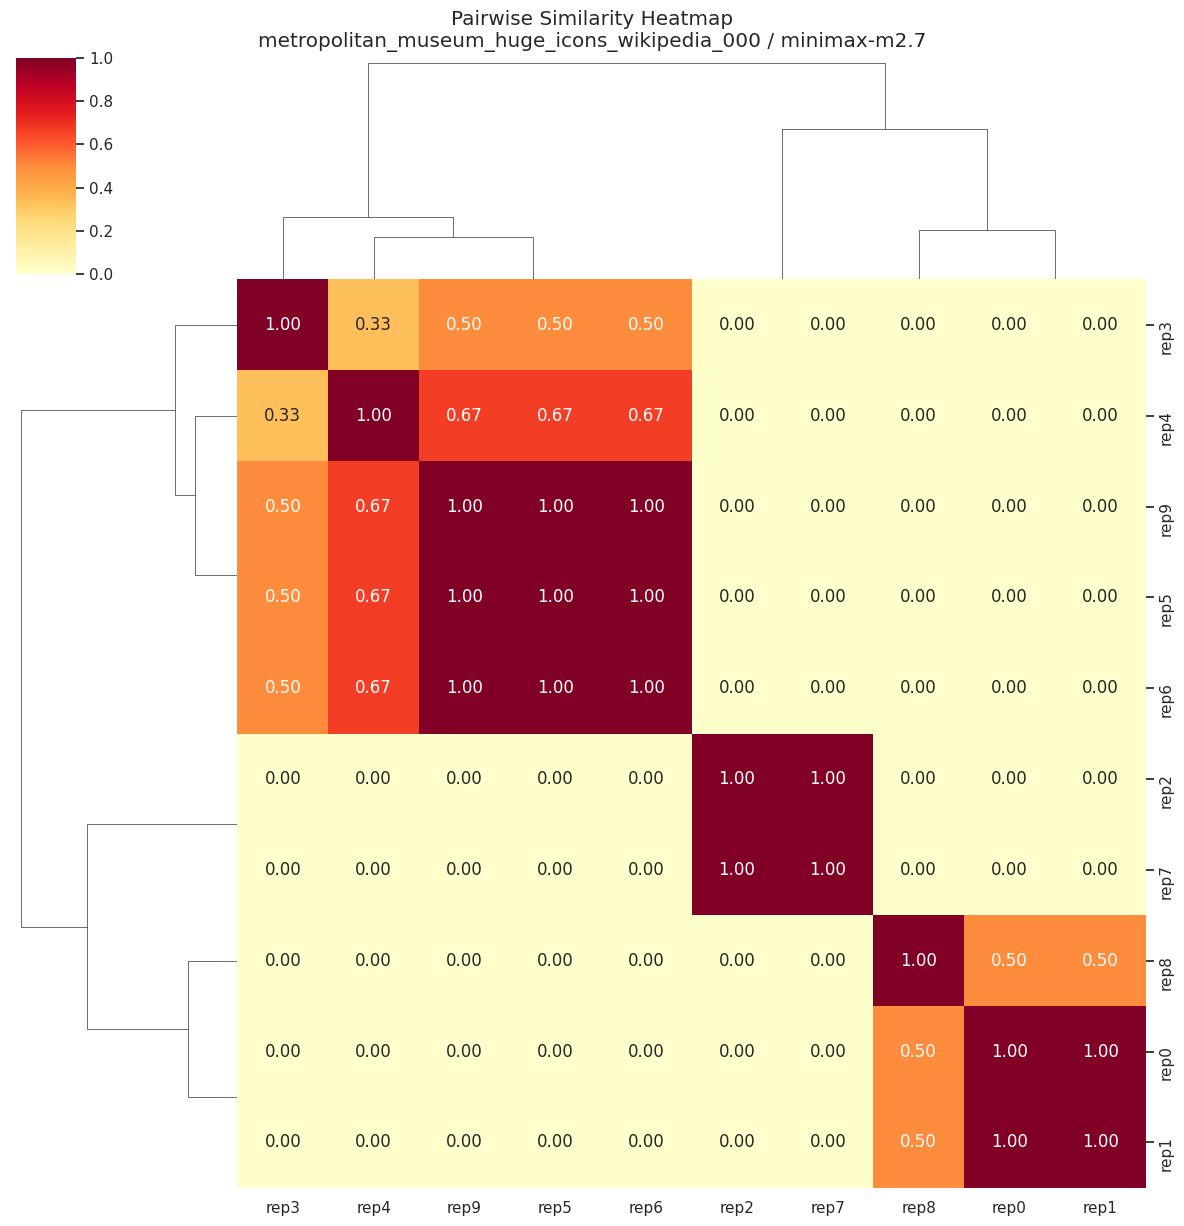

      rep0  rep1  rep2      rep3      rep4      rep5      rep6  rep7  rep8      rep9
rep0   1.0   1.0   0.0  0.000000  0.000000  0.000000  0.000000   0.0   0.5  0.000000
rep1   1.0   1.0   0.0  0.000000  0.000000  0.000000  0.000000   0.0   0.5  0.000000
rep2   0.0   0.0   1.0  0.000000  0.000000  0.000000  0.000000   1.0   0.0  0.000000
rep3   0.0   0.0   0.0  1.000000  0.333333  0.500000  0.500000   0.0   0.0  0.500000
rep4   0.0   0.0   0.0  0.333333  1.000000  0.666667  0.666667   0.0   0.0  0.666667
rep5   0.0   0.0   0.0  0.500000  0.666667  1.000000  1.000000   0.0   0.0  1.000000
rep6   0.0   0.0   0.0  0.500000  0.666667  1.000000  1.000000   0.0   0.0  1.000000
rep7   0.0   0.0   1.0  0.000000  0.000000  0.000000  0.000000   1.0   0.0  0.000000
rep8   0.5   0.5   0.0  0.000000  0.000000  0.000000  0.000000   0.0   1.0  0.000000
rep9   0.0   0.0   0.0  0.500000  0.666667  1.000000  1.000000   0.0   0.0  1.000000


In [76]:
# ── Selectable variables ────────────────────────────────────────────────────
viz_task_id      = consistency_df["task_id"].iloc[0]
viz_variation_id = consistency_df["variation_id"].iloc[0]
viz_model        = consistency_df["model"].iloc[0]
# ────────────────────────────────────────────────────────────────────────────

group_items = sorted(
    [(rep, G) for (tid, vid, m, rep), G in llm_graphs.items()
     if tid == viz_task_id and vid == viz_variation_id and m == viz_model and (tid, vid, m, rep) not in EXCLUDED]
)
group_reps   = [r for r, _ in group_items]
graphs_list  = [G for _, G in group_items]

sim_mat = pairwise_similarity_matrix(graphs_list)
labels  = [f"rep{r}" for r in group_reps]
sim_df  = pd.DataFrame(sim_mat, index=labels, columns=labels)

if len(graphs_list) > 1:
    g = sns.clustermap(
        sim_df, method="ward", metric="euclidean",
        vmin=0, vmax=1, cmap="YlOrRd",
        figsize=(max(5, len(graphs_list) + 2), max(5, len(graphs_list) + 2)),
        annot=True, fmt=".2f",
    )
    g.fig.suptitle(f"Pairwise Similarity Heatmap\n{viz_task_id} / {viz_model}", y=1.02)
    g.fig.savefig(FIGURES_DIR / "similarity_heatmap.png", bbox_inches="tight")
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(sim_df, vmin=0, vmax=1, cmap="YlOrRd", annot=True, fmt=".2f", ax=ax)
    ax.set_title(f"Similarity Matrix\n{viz_task_id} / {viz_model}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "similarity_heatmap.png", bbox_inches="tight")
    plt.show()

print(sim_df.to_string())

### 8.2 — MDS scatter plot

**Purpose:** Embed all repetition graphs for a given task into 2D using Multidimensional Scaling on the pairwise distance matrix (`1 - similarity`), and plot as a scatter coloured by model.

MDS preserves pairwise distances in 2D as faithfully as possible, so clusters of points represent groups of structurally similar plans. If all models' runs form a single tight cluster, they broadly agree on the plan structure. If models form separate clusters, each model has a distinct planning style for this task.

Annotate each point with its repetition index. Include a stress value annotation to indicate how well the 2D embedding preserves the true pairwise distances.

/home/maxro/miniconda3/envs/mcpbench/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


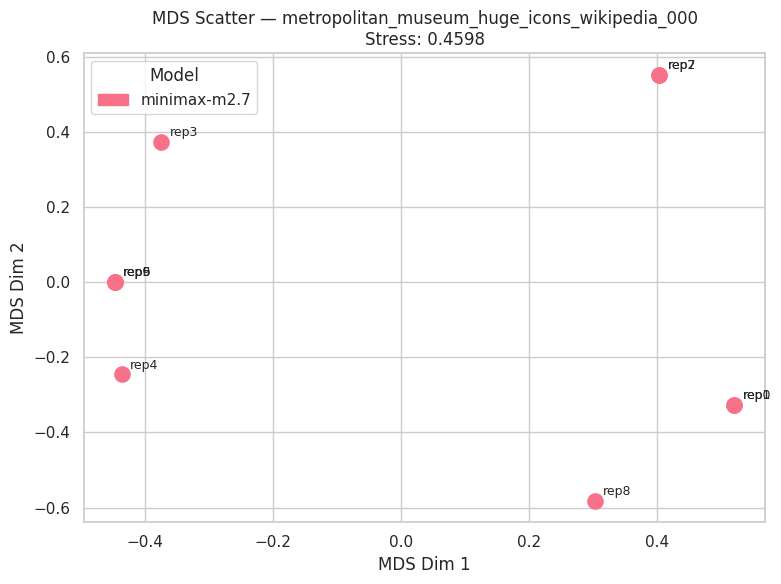

MDS stress: 0.4598  (lower → embedding preserves distances better)


In [77]:
# ── Selectable variable ──────────────────────────────────────────────────────
viz_task_id      = consistency_df["task_id"].iloc[0]
viz_variation_id = consistency_df["variation_id"].iloc[0]
# ────────────────────────────────────────────────────────────────────────────

task_items = sorted(
    [(model, rep, G) for (tid, vid, model, rep), G in llm_graphs.items()
     if tid == viz_task_id and vid == viz_variation_id and (tid, vid, model, rep) not in EXCLUDED]
)
task_graphs = [G for _, _, G in task_items]
task_labels = [(m, r) for m, r, _ in task_items]

if len(task_graphs) < 2:
    print(f"Only {len(task_graphs)} valid graph(s) for '{viz_task_id}' — need ≥ 2 for MDS.")
else:
    sim_mat   = pairwise_similarity_matrix(task_graphs)
    dist_mat  = np.clip(1 - sim_mat, 0, None)
    mds       = MDS(n_components=2, dissimilarity="precomputed",
                    random_state=random_seed, normalized_stress="auto")
    coords    = mds.fit_transform(dist_mat)
    stress    = float(mds.stress_)

    models_present = sorted(set(m for m, _ in task_labels))
    palette        = sns.color_palette("husl", len(models_present))
    model_color    = {m: palette[i] for i, m in enumerate(models_present)}

    fig, ax = plt.subplots(figsize=(8, 6))
    for i, (model, rep) in enumerate(task_labels):
        ax.scatter(coords[i, 0], coords[i, 1], color=model_color[model], s=120, zorder=3)
        ax.annotate(f"rep{rep}", (coords[i, 0], coords[i, 1]),
                    textcoords="offset points", xytext=(6, 4), fontsize=9)

    handles = [mpatches.Patch(color=c, label=m) for m, c in model_color.items()]
    ax.legend(handles=handles, title="Model")
    ax.set_title(f"MDS Scatter — {viz_task_id}\nStress: {stress:.4f}")
    ax.set_xlabel("MDS Dim 1")
    ax.set_ylabel("MDS Dim 2")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "mds_scatter.png", bbox_inches="tight")
    plt.show()
    print(f"MDS stress: {stress:.4f}  (lower → embedding preserves distances better)")

### 8.3 — Graph overlay: LLM prediction vs. ground truth

**Purpose:** Draw a single LLM graph side-by-side with its ground truth, using colour to indicate the status of each node and edge.

Node colouring:
- **Green** — present in both ground truth and prediction (correct)
- **Red** — present in prediction but not ground truth (hallucinated)
- **Grey with dashed border** — present in ground truth but missing from prediction

Edge colouring follows the same scheme. Direction errors (reversed edges) should be shown in amber.

Use a hierarchical layout keyed on topological generation so the DAG structure reads top-to-bottom. Default to showing the centroid run (from `variability_stats`) alongside the ground truth. Make `task_id`, `model`, and `rep` selectable at the top of the cell.

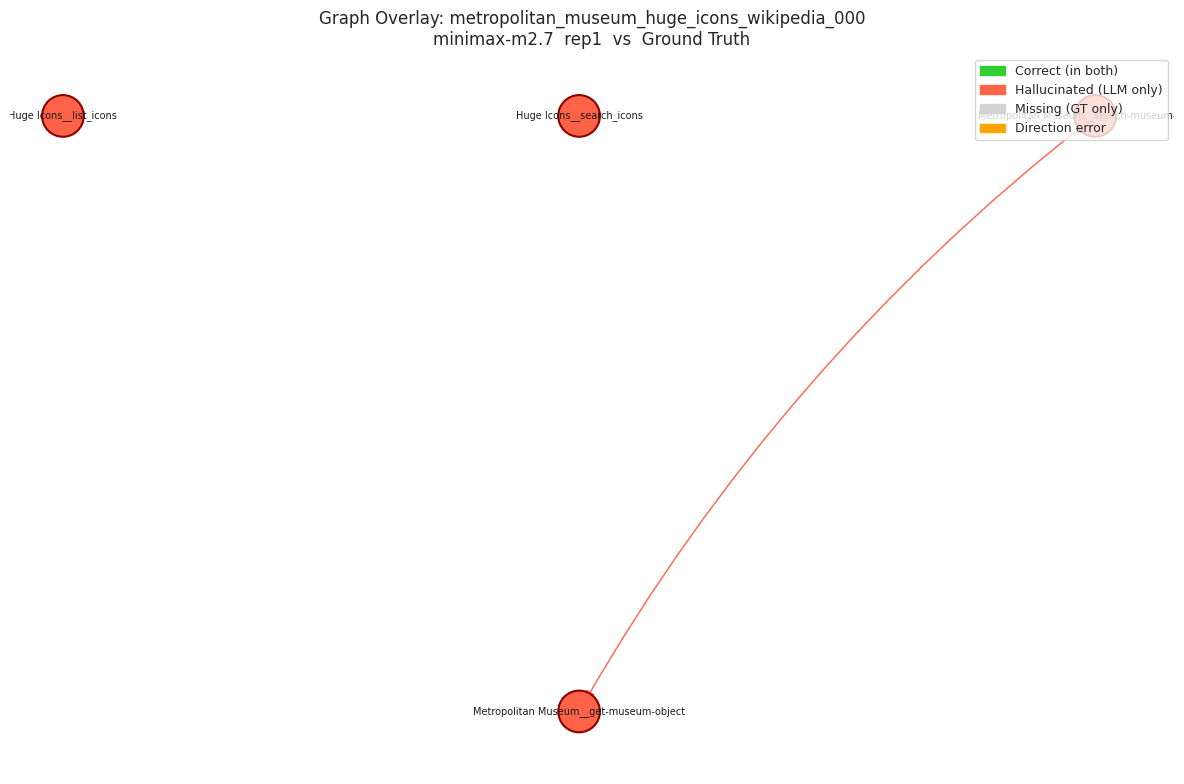

In [78]:
# ── Selectable variables ────────────────────────────────────────────────────
viz_task_id      = consistency_df["task_id"].iloc[0]
viz_variation_id = consistency_df["variation_id"].iloc[1]
viz_model        = consistency_df["model"].iloc[0]
# centroid rep (from consistency_df)
_row = consistency_df.loc[
    (consistency_df["task_id"] == viz_task_id) & (consistency_df["variation_id"] == viz_variation_id) & (consistency_df["model"] == viz_model)
].iloc[0]
_sorted_reps = sorted(
    rep for (tid, vid, m, rep) in llm_graphs if tid == viz_task_id and vid == viz_variation_id and m == viz_model
)
viz_rep = _sorted_reps[int(_row["centroid_idx"])]
# ────────────────────────────────────────────────────────────────────────────

G_pred = llm_graphs[(viz_task_id, viz_variation_id, viz_model, viz_rep)]
G_gt   = ground_truth_graphs[viz_task_id]

pred_nodes = set(G_pred.nodes())
gt_nodes   = set(G_gt.nodes())
pred_edges = set(G_pred.edges())
gt_edges   = set(G_gt.edges())

all_nodes = pred_nodes | gt_nodes
G_combined = nx.DiGraph()
G_combined.add_nodes_from(all_nodes)
G_combined.add_edges_from(pred_edges | gt_edges)

# Hierarchical topological layout
try:
    layers = list(nx.topological_generations(G_combined))
    pos = {}
    for ly_idx, layer in enumerate(layers):
        layer = sorted(layer)
        for nd_idx, node in enumerate(layer):
            pos[node] = (nd_idx - (len(layer) - 1) / 2.0, -ly_idx)
except Exception:
    pos = nx.spring_layout(G_combined, seed=random_seed)

# Node colours
node_face  = []
node_edge_c = []
for node in G_combined.nodes():
    if node in pred_nodes and node in gt_nodes:
        node_face.append("limegreen");  node_edge_c.append("darkgreen")
    elif node in pred_nodes:
        node_face.append("tomato");     node_edge_c.append("darkred")
    else:
        node_face.append("lightgrey");  node_edge_c.append("grey")

# Edge colours
fig, ax = plt.subplots(figsize=(max(12, len(all_nodes) * 1.5), max(8, len(all_nodes))))
nx.draw_networkx_nodes(G_combined, pos, node_color=node_face,
                       edgecolors=node_edge_c, linewidths=1.5, node_size=900, ax=ax)
nx.draw_networkx_labels(G_combined, pos, ax=ax, font_size=7)

for u, v in G_combined.edges():
    in_pred = (u, v) in pred_edges
    in_gt   = (u, v) in gt_edges
    if in_pred and in_gt:
        color = "limegreen"
    elif in_pred and (v, u) in gt_edges:
        color = "orange"     # direction error
    elif in_pred:
        color = "tomato"     # hallucinated edge
    else:
        color = "lightgrey"  # missing edge (GT only)
    nx.draw_networkx_edges(G_combined, pos, edgelist=[(u, v)],
                           edge_color=color, arrows=True, arrowsize=15,
                           connectionstyle="arc3,rad=0.1", ax=ax)

legend_els = [
    mpatches.Patch(color="limegreen", label="Correct (in both)"),
    mpatches.Patch(color="tomato",    label="Hallucinated (LLM only)"),
    mpatches.Patch(color="lightgrey", label="Missing (GT only)"),
    mpatches.Patch(color="orange",    label="Direction error"),
]
ax.legend(handles=legend_els, loc="upper right", fontsize=9)
ax.set_title(f"Graph Overlay: {viz_task_id}\n{viz_model}  rep{viz_rep}  vs  Ground Truth")
ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "graph_overlay.png", bbox_inches="tight")
plt.show()

### 8.4 — Edge stability bar chart

**Purpose:** For a selected `(task_id, model)`, plot each unique edge `(u→v)` seen across all repetitions on the x-axis, with its appearance frequency on the y-axis.

Colour bars by status relative to the ground truth:
- **Green** — edge is in the ground truth and frequently appears (correct and stable)
- **Amber** — edge is in the ground truth but rarely appears (correct but unstable)
- **Red** — edge is not in the ground truth but frequently appears (stable hallucination)
- **Light red** — edge is not in the ground truth and rarely appears (noisy hallucination)

Sort bars by frequency descending. Draw a horizontal dashed line at the threshold used to define certain vs. flickering edges. This makes the raw edge stability data from Section 5 directly interpretable.

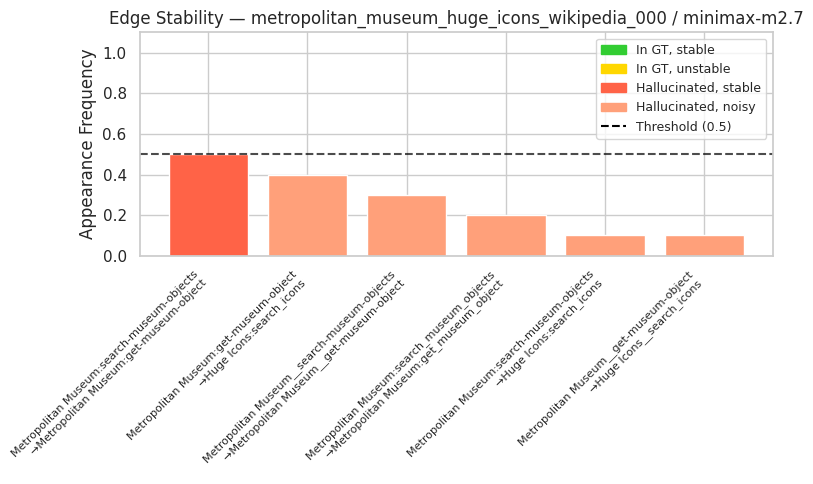

In [79]:
# ── Selectable variables ────────────────────────────────────────────────────
viz_task_id      = consistency_df["task_id"].iloc[0]
viz_variation_id = consistency_df["variation_id"].iloc[0]
viz_model        = consistency_df["model"].iloc[0]
# ────────────────────────────────────────────────────────────────────────────

group_edges = {
    (u, v): freq
    for (tid, vid, m, u, v), freq in edge_stability.items()
    if tid == viz_task_id and vid == viz_variation_id and m == viz_model
}

if not group_edges:
    print(f"No edges found for ({viz_task_id!r}, {viz_model!r}).")
else:
    gt_edges = set(ground_truth_graphs[viz_task_id].edges())
    sorted_edges = sorted(group_edges.items(), key=lambda x: -x[1])
    x_labels = [f"{u}\n→{v}" for (u, v), _ in sorted_edges]
    freqs    = [freq for _, freq in sorted_edges]

    bar_colors = []
    for (u, v), freq in sorted_edges:
        in_gt = (u, v) in gt_edges
        if   in_gt and freq >= SIMILARITY_THRESHOLD:  bar_colors.append("limegreen")
        elif in_gt:                                    bar_colors.append("gold")
        elif freq >= SIMILARITY_THRESHOLD:             bar_colors.append("tomato")
        else:                                          bar_colors.append("lightsalmon")

    fig, ax = plt.subplots(figsize=(max(8, len(x_labels) * 1.1), 5))
    ax.bar(range(len(x_labels)), freqs, color=bar_colors)
    ax.axhline(SIMILARITY_THRESHOLD, color="black", linestyle="--", alpha=0.7,
               label=f"Threshold ({SIMILARITY_THRESHOLD})")
    ax.set_xticks(range(len(x_labels)))
    ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Appearance Frequency")
    ax.set_title(f"Edge Stability — {viz_task_id} / {viz_model}")

    legend_els = [
        mpatches.Patch(color="limegreen",   label="In GT, stable"),
        mpatches.Patch(color="gold",        label="In GT, unstable"),
        mpatches.Patch(color="tomato",      label="Hallucinated, stable"),
        mpatches.Patch(color="lightsalmon", label="Hallucinated, noisy"),
        plt.Line2D([0], [0], color="black", linestyle="--",
                   label=f"Threshold ({SIMILARITY_THRESHOLD})"),
    ]
    ax.legend(handles=legend_els, loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "edge_stability.png", bbox_inches="tight")
    plt.show()

### 8.5 — Consistency vs. accuracy scatter

**Purpose:** Plot each `(task_id, model)` group as a point with mean consistency score (edge Jaccard across reps) on the x-axis and mean edge F1 against ground truth on the y-axis. Colour points by model.

This produces a 2×2 quadrant view of model behaviour:
- **Top-right** — consistent and accurate: the model reliably produces correct plans
- **Top-left** — inconsistent but accurate on average: sometimes right but varies widely
- **Bottom-right** — consistent but wrong: reliably produces the same incorrect plan
- **Bottom-left** — inconsistent and inaccurate: chaotic and incorrect

The bottom-right quadrant is the most analytically interesting: tasks where the model is highly self-consistent but diverges from ground truth suggest a systematic misunderstanding of the task rather than stochastic noise.

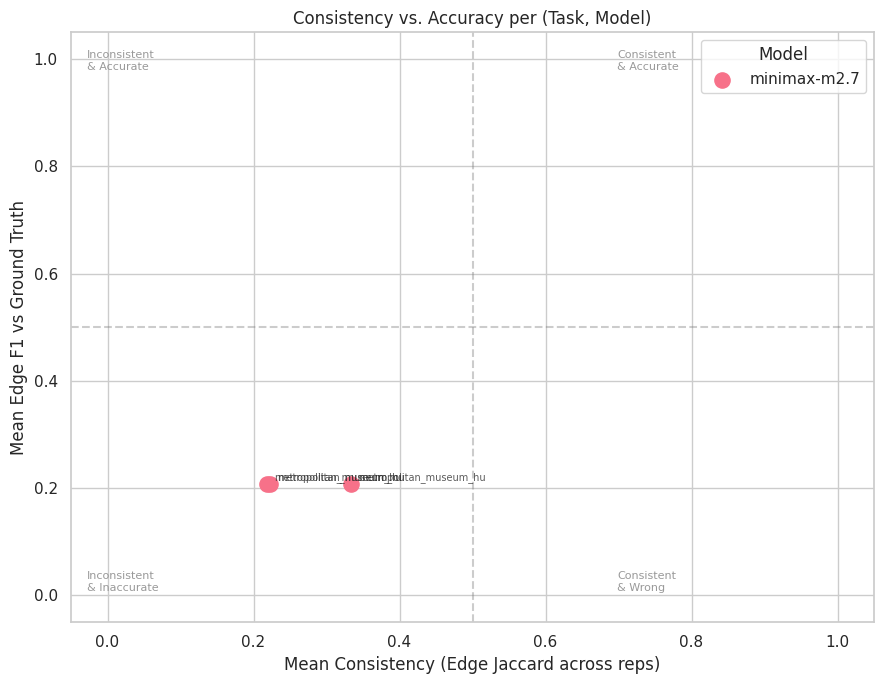

In [80]:
mean_f1_per_group = (
    error_df.groupby(["task_id", "model"])["edge_f1"]
    .mean().reset_index()
    .rename(columns={"edge_f1": "mean_f1"})
)
scatter_df = consistency_df.merge(mean_f1_per_group, on=["task_id", "model"])

models_uniq = scatter_df["model"].unique()
palette     = sns.color_palette("husl", len(models_uniq))
model_color = {m: palette[i] for i, m in enumerate(models_uniq)}

fig, ax = plt.subplots(figsize=(9, 7))
for model in models_uniq:
    sub = scatter_df[scatter_df["model"] == model]
    ax.scatter(sub["mean_similarity"], sub["mean_f1"],
               color=model_color[model], s=120, label=model, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row["task_id"][:22], (row["mean_similarity"], row["mean_f1"]),
                    textcoords="offset points", xytext=(5, 3), fontsize=7, alpha=0.75)

ax.axvline(0.5, color="grey", linestyle="--", alpha=0.4)
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.4)
for (tx, ty, label) in [
    (0.02, 0.97, "Inconsistent\n& Accurate"),
    (0.68, 0.97, "Consistent\n& Accurate"),
    (0.02, 0.05, "Inconsistent\n& Inaccurate"),
    (0.68, 0.05, "Consistent\n& Wrong"),
]:
    ax.text(tx, ty, label, transform=ax.transAxes, fontsize=8, va="top" if ty > 0.5 else "bottom",
            color="grey", alpha=0.8)

ax.set_xlabel("Mean Consistency (Edge Jaccard across reps)")
ax.set_ylabel("Mean Edge F1 vs Ground Truth")
ax.set_title("Consistency vs. Accuracy per (Task, Model)")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend(title="Model")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "consistency_vs_accuracy.png", bbox_inches="tight")
plt.show()

### 8.6 — Task difficulty dendrogram

**Purpose:** Cluster tasks by their full difficulty profile vector and display as a dendrogram.

Each task is represented as a feature vector containing: mean edge F1 averaged across models, mean consistency score, ground truth node count, ground truth edge count, and longest path length. Hierarchical clustering with Ward linkage on this vector groups tasks that are jointly hard or easy in the same structural ways.

The dendrogram reveals whether difficulty clusters structurally — for example, whether all multi-server tasks cluster together, or whether long critical path tasks form their own group. Annotate leaf nodes with task identifiers and optionally colour them by a known task metadata field (domain, server count) to test whether structural clusters align with known task categories.

In [81]:
from scipy.cluster.hierarchy import dendrogram as _dendrogram

feature_rows = []
task_ids_dendro = []

for task_id, G_gt in ground_truth_graphs.items():
    task_errs = error_df[error_df["task_id"] == task_id]
    task_cons = consistency_df[consistency_df["task_id"] == task_id]

    mean_f1          = task_errs["edge_f1"].mean()          if not task_errs.empty else 0.0
    mean_consistency = task_cons["mean_similarity"].mean()  if not task_cons.empty else 0.0
    gt_nodes         = G_gt.number_of_nodes()
    gt_edges         = G_gt.number_of_edges()
    longest_path     = nx.dag_longest_path_length(G_gt) if gt_nodes > 0 else 0

    feature_rows.append([mean_f1, mean_consistency, gt_nodes, gt_edges, longest_path])
    task_ids_dendro.append(task_id)

if len(feature_rows) < 2:
    print(f"Only {len(feature_rows)} task(s) — need ≥ 2 for clustering.")
    print("Tasks present:")
    for tid in task_ids_dendro:
        print(f"  {tid}")
else:
    X = np.array(feature_rows, dtype=float)
    stds = X.std(axis=0)
    stds[stds == 0] = 1.0
    X_norm = (X - X.mean(axis=0)) / stds

    Z = linkage(X_norm, method="ward")

    fig, ax = plt.subplots(figsize=(max(8, len(task_ids_dendro) * 1.5), 6))
    _dendrogram(Z, labels=[t[:35] for t in task_ids_dendro], ax=ax, leaf_rotation=45)
    ax.set_title("Task Difficulty Dendrogram (Ward linkage, 5-feature vector)")
    ax.set_ylabel("Ward Distance")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "task_dendrogram.png", bbox_inches="tight")
    plt.show()

Only 1 task(s) — need ≥ 2 for clustering.
Tasks present:
  metropolitan_museum_huge_icons_wikipedia_000
